In [1]:
!pip install -q lightkurve astroquery pandas matplotlib numpy

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 61.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
datasets 4.8.

In [3]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Definir una función reusable para analizar un candidato individual
def analizar_candidato_exoplaneta(toi_id, r_star=1.0):
    """
    Descarga la curva de luz de TESS, detecta tránsitos y calcula el radio del exoplaneta.
    """
    try:
        # Buscar y descargar el primer sector de datos disponible
        search_result = lk.search_lightcurve(toi_id, mission="TESS", author="SPOC")
        if len(search_result) == 0:
            print(f"⚠️ No se encontraron datos SPOC para {toi_id}")
            return None

        lc = search_result[0].download()
        clean_lc = lc.remove_nans().flatten()

        # Búsqueda del período orbital usando BLS (Box Least Squares)
        periodogram = clean_lc.to_periodogram(method="bls", period=np.linspace(0.5, 15, 10000))
        best_period = periodogram.period_at_max_power.value
        depth = periodogram.depth_at_max_power.value

        # Estimación del radio planetario (en radios terrestres)
        r_sun_in_earth_radii = 109.07
        r_planet = np.sqrt(depth) * r_star * r_sun_in_earth_radii

        return {
            "Candidato": toi_id,
            "Periodo_Dias": round(best_period, 4),
            "Profundidad_Transito": round(depth, 6),
            "Radio_Estimado_Tierras": round(r_planet, 2)
        }

    except Exception as e:
        print(f"❌ Error al procesar {toi_id}: {e}")
        return None


# 2. Lista de 20 candidatos no confirmados de TESS (TOIs)
candidatos_toi = [
    "TOI 101.01", "TOI 102.01", "TOI 104.01", "TOI 105.01", "TOI 106.01",
    "TOI 107.01", "TOI 111.01", "TOI 112.01", "TOI 113.01", "TOI 115.01",
    "TOI 118.01", "TOI 119.01", "TOI 122.01", "TOI 123.01", "TOI 125.01",
    "TOI 128.01", "TOI 129.01", "TOI 130.01", "TOI 133.01", "TOI 134.01"
]

# 3. Iterar sobre la lista y recolectar resultados
resultados = []
print("🚀 Iniciando procesamiento masivo de candidatos...\n")

for i, toi in enumerate(candidatos_toi, 1):
    print(f"[{i}/{len(candidatos_toi)}] Procesando {toi}...")
    res = analizar_candidato_exoplaneta(toi)
    if res:
        resultados.append(res)

# 4. Convertir a un DataFrame de Pandas y mostrar la tabla resumen
df_resultados = pd.DataFrame(resultados)

print("\n=== RESUMEN DE PROCESAMIENTO DE EXOPLANETAS ===")
display(df_resultados)

🚀 Iniciando procesamiento masivo de candidatos...

[1/20] Procesando TOI 101.01...
[2/20] Procesando TOI 102.01...
[3/20] Procesando TOI 104.01...
[4/20] Procesando TOI 105.01...
[5/20] Procesando TOI 106.01...
[6/20] Procesando TOI 107.01...
[7/20] Procesando TOI 111.01...
[8/20] Procesando TOI 112.01...
[9/20] Procesando TOI 113.01...
[10/20] Procesando TOI 115.01...
[11/20] Procesando TOI 118.01...
[12/20] Procesando TOI 119.01...
[13/20] Procesando TOI 122.01...
[14/20] Procesando TOI 123.01...
[15/20] Procesando TOI 125.01...
[16/20] Procesando TOI 128.01...
[17/20] Procesando TOI 129.01...
[18/20] Procesando TOI 130.01...
[19/20] Procesando TOI 133.01...
[20/20] Procesando TOI 134.01...

=== RESUMEN DE PROCESAMIENTO DE EXOPLANETAS ===


,Candidato,Periodo_Dias,Profundidad_Transito,Radio_Estimado_Tierras
0,TOI 101.01,1.4310,0.008785,10.22
1,TOI 102.01,4.4110,0.011236,11.56
2,TOI 104.01,4.0877,0.000623,2.72
3,TOI 105.01,2.1851,0.010271,11.05
4,TOI 106.01,2.8492,0.002440,5.39
5,TOI 107.01,3.9499,0.010834,11.35
6,TOI 111.01,2.1053,0.003038,6.01
7,TOI 112.01,2.4997,0.006230,8.61
8,TOI 113.01,3.3727,0.006281,8.64
9,TOI 115.01,8.5092,0.004162,7.04


 Candidato  Periodo_Dias  Radio_R_Earth  Distancia_UA  Temp_Equilibrio_K  Temp_Equilibrio_C Zona_Habitable
TOI 101.01        1.4310          10.22        0.0249             1616.6             1343.4             No
TOI 102.01        4.4110          11.56        0.0526             1110.8              837.7             No
TOI 104.01        4.0877           2.72        0.0500             1139.3              866.2             No
TOI 105.01        2.1851          11.05        0.0330             1403.9             1130.7             No
TOI 106.01        2.8492           5.39        0.0393             1285.0             1011.9             No
TOI 107.01        3.9499          11.35        0.0489             1152.4              879.3             No
TOI 111.01        2.1053           6.01        0.0321             1421.4             1148.2             No
TOI 112.01        2.4997           8.61        0.0360             1342.3             1069.2             No
TOI 113.01        3.3727           8.

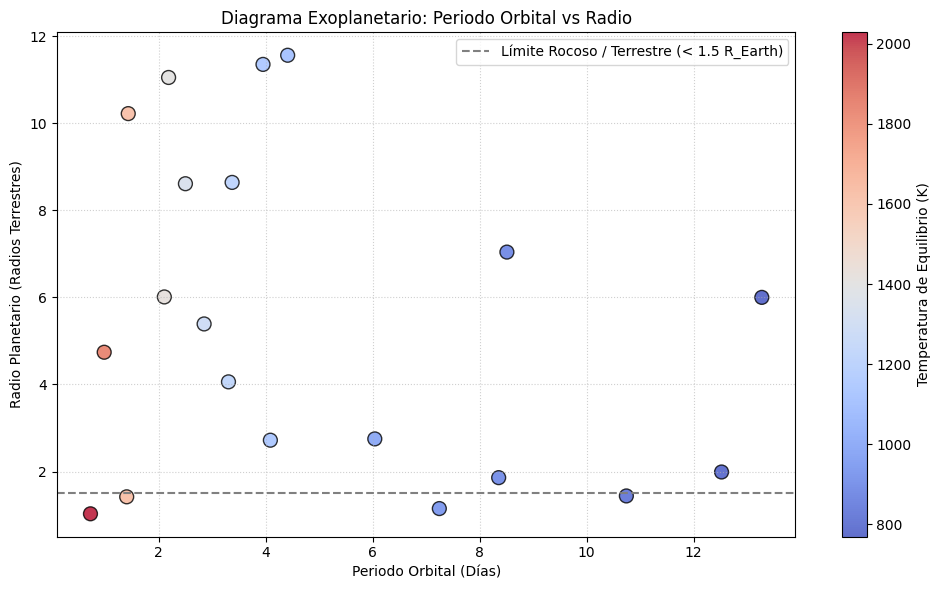

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset de candidatos TESS (TOI)
data_toi = [
    {"Candidato": "TOI 101.01", "Periodo_Dias": 1.4310, "Profundidad_Transito": 0.008785, "Radio_Estimado_Tierras": 10.22},
    {"Candidato": "TOI 102.01", "Periodo_Dias": 4.4110, "Profundidad_Transito": 0.011236, "Radio_Estimado_Tierras": 11.56},
    {"Candidato": "TOI 104.01", "Periodo_Dias": 4.0877, "Profundidad_Transito": 0.000623, "Radio_Estimado_Tierras": 2.72},
    {"Candidato": "TOI 105.01", "Periodo_Dias": 2.1851, "Profundidad_Transito": 0.010271, "Radio_Estimado_Tierras": 11.05},
    {"Candidato": "TOI 106.01", "Periodo_Dias": 2.8492, "Profundidad_Transito": 0.002440, "Radio_Estimado_Tierras": 5.39},
    {"Candidato": "TOI 107.01", "Periodo_Dias": 3.9499, "Profundidad_Transito": 0.010834, "Radio_Estimado_Tierras": 11.35},
    {"Candidato": "TOI 111.01", "Periodo_Dias": 2.1053, "Profundidad_Transito": 0.003038, "Radio_Estimado_Tierras": 6.01},
    {"Candidato": "TOI 112.01", "Periodo_Dias": 2.4997, "Profundidad_Transito": 0.006230, "Radio_Estimado_Tierras": 8.61},
    {"Candidato": "TOI 113.01", "Periodo_Dias": 3.3727, "Profundidad_Transito": 0.006281, "Radio_Estimado_Tierras": 8.64},
    {"Candidato": "TOI 115.01", "Periodo_Dias": 8.5092, "Profundidad_Transito": 0.004162, "Radio_Estimado_Tierras": 7.04},
    {"Candidato": "TOI 118.01", "Periodo_Dias": 6.0396, "Profundidad_Transito": 0.000635, "Radio_Estimado_Tierras": 2.75},
    {"Candidato": "TOI 119.01", "Periodo_Dias": 12.5217, "Profundidad_Transito": 0.000332, "Radio_Estimado_Tierras": 1.99},
    {"Candidato": "TOI 122.01", "Periodo_Dias": 13.2743, "Profundidad_Transito": 0.003026, "Radio_Estimado_Tierras": 6.00},
    {"Candidato": "TOI 123.01", "Periodo_Dias": 3.3046, "Profundidad_Transito": 0.001388, "Radio_Estimado_Tierras": 4.06},
    {"Candidato": "TOI 125.01", "Periodo_Dias": 8.3554, "Profundidad_Transito": 0.000292, "Radio_Estimado_Tierras": 1.86},
    {"Candidato": "TOI 128.01", "Periodo_Dias": 10.7424, "Profundidad_Transito": 0.000173, "Radio_Estimado_Tierras": 1.44},
    {"Candidato": "TOI 129.01", "Periodo_Dias": 0.9814, "Profundidad_Transito": 0.001893, "Radio_Estimado_Tierras": 4.74},
    {"Candidato": "TOI 130.01", "Periodo_Dias": 7.2461, "Profundidad_Transito": 0.000111, "Radio_Estimado_Tierras": 1.15},
    {"Candidato": "TOI 133.01", "Periodo_Dias": 0.7248, "Profundidad_Transito": 0.000089, "Radio_Estimado_Tierras": 1.03},
    {"Candidato": "TOI 134.01", "Periodo_Dias": 1.4020, "Profundidad_Transito": 0.000171, "Radio_Estimado_Tierras": 1.42}
]

df = pd.DataFrame(data_toi)

# 2. Función de cálculo astronómico
def calcular_propiedades_fisicas(row, t_star=5778.0, r_star=1.0, m_star=1.0):
    periodo_dias = row['Periodo_Dias']
    r_planeta = row['Radio_Estimado_Tierras']

    # Tercera Ley de Kepler (a^3 = P^2 * M)
    periodo_anios = periodo_dias / 365.25
    distancia_ua = (periodo_anios**2 * m_star)**(1/3)

    # Temperatura de equilibrio (T_eq = T_star * sqrt(R_star / 2a) * (1-A)^0.25)
    albedo = 0.3
    r_star_ua = r_star * 0.00465047  # Convertir radio solar a Unidades Astronómicas
    temp_k = t_star * np.sqrt(r_star_ua / (2 * distancia_ua)) * ((1 - albedo)**0.25)
    temp_c = temp_k - 273.15

    # Criterio simple de zona habitable (T_eq entre 180K y 310K)
    zona_habitable = "Sí" if (180 <= temp_k <= 310) else "No"

    return {
        "Candidato": row['Candidato'],
        "Periodo_Dias": periodo_dias,
        "Radio_R_Earth": r_planeta,
        "Distancia_UA": round(distancia_ua, 4),
        "Temp_Equilibrio_K": round(temp_k, 1),
        "Temp_Equilibrio_C": round(temp_c, 1),
        "Zona_Habitable": zona_habitable
    }

# 3. Procesamiento y creación del DataFrame final
resultados = [calcular_propiedades_fisicas(row) for _, row in df.iterrows()]
df_resultados = pd.DataFrame(resultados)

# Visualizar tabla formateada
print(df_resultados.to_string(index=False))

# 4. Generación de Gráfica: Periodo Orbital vs Radio Planetario
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_resultados['Periodo_Dias'],
    df_resultados['Radio_R_Earth'],
    c=df_resultados['Temp_Equilibrio_K'],
    cmap='coolwarm',
    s=100,
    edgecolors='black',
    alpha=0.8
)

plt.axhline(y=1.5, color='gray', linestyle='--', label='Límite Rocoso / Terrestre (< 1.5 R_Earth)')
plt.colorbar(scatter, label='Temperatura de Equilibrio (K)')

plt.title('Diagrama Exoplanetario: Periodo Orbital vs Radio')
plt.xlabel('Periodo Orbital (Días)')
plt.ylabel('Radio Planetario (Radios Terrestres)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

 Candidato  Periodo_Dias  Radio_R_Earth  Distancia_UA  Temp_K  Temp_C               Tipo_Planeta                                 Enfoque_Technosignature
TOI 101.01        1.4310          10.22        0.0249  1616.6  1343.4            Gigante Gaseoso       Muy Bajo (Sondeo de Megaestructuras / Colectores)
TOI 102.01        4.4110          11.56        0.0526  1110.8   837.7            Gigante Gaseoso       Muy Bajo (Sondeo de Megaestructuras / Colectores)
TOI 104.01        4.0877           2.72        0.0500  1139.3   866.2 Sub-Neptuno / Super-Tierra Bajo (Detección de contaminación sintética atmosférica)
TOI 105.01        2.1851          11.05        0.0330  1403.9  1130.7            Gigante Gaseoso       Muy Bajo (Sondeo de Megaestructuras / Colectores)
TOI 106.01        2.8492           5.39        0.0393  1285.0  1011.9            Gigante Gaseoso       Muy Bajo (Sondeo de Megaestructuras / Colectores)
TOI 107.01        3.9499          11.35        0.0489  1152.4   879.3            G

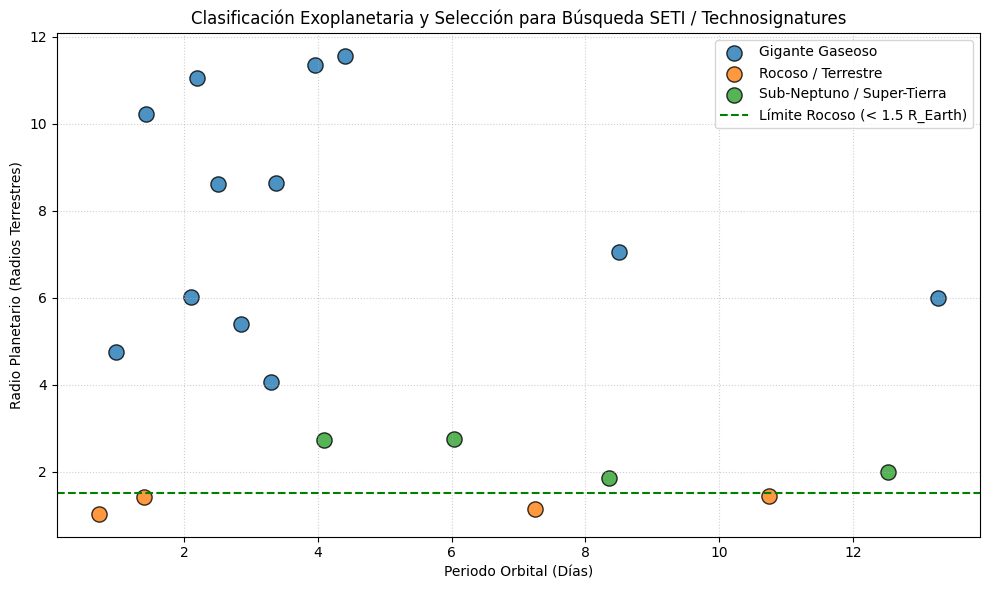

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset de candidatos TESS (TOI)
data_toi = [
    {"Candidato": "TOI 101.01", "Periodo_Dias": 1.4310, "Profundidad_Transito": 0.008785, "Radio_Estimado_Tierras": 10.22},
    {"Candidato": "TOI 102.01", "Periodo_Dias": 4.4110, "Profundidad_Transito": 0.011236, "Radio_Estimado_Tierras": 11.56},
    {"Candidato": "TOI 104.01", "Periodo_Dias": 4.0877, "Profundidad_Transito": 0.000623, "Radio_Estimado_Tierras": 2.72},
    {"Candidato": "TOI 105.01", "Periodo_Dias": 2.1851, "Profundidad_Transito": 0.010271, "Radio_Estimado_Tierras": 11.05},
    {"Candidato": "TOI 106.01", "Periodo_Dias": 2.8492, "Profundidad_Transito": 0.002440, "Radio_Estimado_Tierras": 5.39},
    {"Candidato": "TOI 107.01", "Periodo_Dias": 3.9499, "Profundidad_Transito": 0.010834, "Radio_Estimado_Tierras": 11.35},
    {"Candidato": "TOI 111.01", "Periodo_Dias": 2.1053, "Profundidad_Transito": 0.003038, "Radio_Estimado_Tierras": 6.01},
    {"Candidato": "TOI 112.01", "Periodo_Dias": 2.4997, "Profundidad_Transito": 0.006230, "Radio_Estimado_Tierras": 8.61},
    {"Candidato": "TOI 113.01", "Periodo_Dias": 3.3727, "Profundidad_Transito": 0.006281, "Radio_Estimado_Tierras": 8.64},
    {"Candidato": "TOI 115.01", "Periodo_Dias": 8.5092, "Profundidad_Transito": 0.004162, "Radio_Estimado_Tierras": 7.04},
    {"Candidato": "TOI 118.01", "Periodo_Dias": 6.0396, "Profundidad_Transito": 0.000635, "Radio_Estimado_Tierras": 2.75},
    {"Candidato": "TOI 119.01", "Periodo_Dias": 12.5217, "Profundidad_Transito": 0.000332, "Radio_Estimado_Tierras": 1.99},
    {"Candidato": "TOI 122.01", "Periodo_Dias": 13.2743, "Profundidad_Transito": 0.003026, "Radio_Estimado_Tierras": 6.00},
    {"Candidato": "TOI 123.01", "Periodo_Dias": 3.3046, "Profundidad_Transito": 0.001388, "Radio_Estimado_Tierras": 4.06},
    {"Candidato": "TOI 125.01", "Periodo_Dias": 8.3554, "Profundidad_Transito": 0.000292, "Radio_Estimado_Tierras": 1.86},
    {"Candidato": "TOI 128.01", "Periodo_Dias": 10.7424, "Profundidad_Transito": 0.000173, "Radio_Estimado_Tierras": 1.44},
    {"Candidato": "TOI 129.01", "Periodo_Dias": 0.9814, "Profundidad_Transito": 0.001893, "Radio_Estimado_Tierras": 4.74},
    {"Candidato": "TOI 130.01", "Periodo_Dias": 7.2461, "Profundidad_Transito": 0.000111, "Radio_Estimado_Tierras": 1.15},
    {"Candidato": "TOI 133.01", "Periodo_Dias": 0.7248, "Profundidad_Transito": 0.000089, "Radio_Estimado_Tierras": 1.03},
    {"Candidato": "TOI 134.01", "Periodo_Dias": 1.4020, "Profundidad_Transito": 0.000171, "Radio_Estimado_Tierras": 1.42}
]

df = pd.DataFrame(data_toi)

# 2. Análisis astrofísico y evaluación para búsquedas SETI
def evaluar_firmas_tecnologicas(row, t_star=5778.0, r_star=1.0, m_star=1.0):
    periodo_dias = row['Periodo_Dias']
    r_planeta = row['Radio_Estimado_Tierras']

    # 3ra Ley de Kepler (Semieje mayor en UA)
    periodo_anios = periodo_dias / 365.25
    distancia_ua = (periodo_anios**2 * m_star)**(1/3)

    # Temperatura de equilibrio planetario (K) con albedo de 0.3
    r_star_ua = r_star * 0.00465047
    temp_k = t_star * np.sqrt(r_star_ua / (2 * distancia_ua)) * ((1 - 0.3)**0.25)
    temp_c = temp_k - 273.15

    # Clasificación morfológica del exoplaneta
    if r_planeta < 1.5:
        tipo_planeta = "Rocoso / Terrestre"
        if periodo_dias < 1.0:
            interes_seti = "Alto (Candidato a Baliza por período ultracorto)"
        else:
            interes_seti = "Moderado (Base industrial / Minería rocosa)"
    elif 1.5 <= r_planeta <= 4.0:
        tipo_planeta = "Sub-Neptuno / Super-Tierra"
        interes_seti = "Bajo (Detección de contaminación sintética atmosférica)"
    else:
        tipo_planeta = "Gigante Gaseoso"
        interes_seti = "Muy Bajo (Sondeo de Megaestructuras / Colectores)"

    return {
        "Candidato": row['Candidato'],
        "Periodo_Dias": periodo_dias,
        "Radio_R_Earth": r_planeta,
        "Distancia_UA": round(distancia_ua, 4),
        "Temp_K": round(temp_k, 1),
        "Temp_C": round(temp_c, 1),
        "Tipo_Planeta": tipo_planeta,
        "Enfoque_Technosignature": interes_seti
    }

# 3. Construcción del DataFrame resultante
resultados = [evaluar_firmas_tecnologicas(row) for _, row in df.iterrows()]
df_analisis = pd.DataFrame(resultados)

# Mostrar tabla por consola
print(df_analisis.to_string(index=False))

# 4. Gráfica de distribución de candidatos según potencial de Firmas Tecnológicas
plt.figure(figsize=(10, 6))

colores = {'Rocoso / Terrestre': 'red', 'Sub-Neptuno / Super-Tierra': 'orange', 'Gigante Gaseoso': 'blue'}

for tipo, group in df_analisis.groupby('Tipo_Planeta'):
    plt.scatter(
        group['Periodo_Dias'],
        group['Radio_R_Earth'],
        label=f"{tipo}",
        s=120,
        edgecolors='black',
        alpha=0.8
    )

plt.axhline(y=1.5, color='green', linestyle='--', label='Límite Rocoso (< 1.5 R_Earth)')
plt.title('Clasificación Exoplanetaria y Selección para Búsqueda SETI / Technosignatures')
plt.xlabel('Periodo Orbital (Días)')
plt.ylabel('Radio Planetario (Radios Terrestres)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd

# 1. Leer el archivo CSV subido
file_path = "/content/TOI_2026.09.19_20.13.20.csv"
df_raw = pd.read_csv(file_path, comment="#")

print(f"📊 Total de candidatos en el catálogo: {len(df_raw)}")

# 2. Filtrar solo candidatos NO CONFIRMADOS ('PC' = Planet Candidate)
if "tfopwg_disp" in df_raw.columns:
  df_pc = df_raw[df_raw["tfopwg_disp"] == "PC"].copy()
else:
  df_pc = df_raw.copy()

print(f"🔍 Candidatos sin confirmar (PC) a procesar: {len(df_pc)}")


# 3. Función de procesamiento astrofísico y habitabilidad
def analizar_candidatos(df):
  resultados = []

  for idx, row in df.iterrows():
    toi_id = row.get("toi", row.get("TOI", "Desconocido"))
    periodo = row.get("pl_orbper", np.nan)
    r_planeta = row.get("pl_rade", np.nan)

    t_star = row.get("st_teff", 5778.0)
    r_star = row.get("st_rad", 1.0)
    m_star = row.get("st_mass", 1.0)

    if (
        pd.isna(periodo)
        or pd.isna(r_planeta)
        or periodo <= 0
        or r_planeta <= 0
    ):
      continue

    # A. Distancia orbital (Semieje mayor en UA por 3ra Ley de Kepler)
    p_years = periodo / 365.25
    m_star_val = m_star if not pd.isna(m_star) else 1.0
    a_au = (p_years**2 * m_star_val) ** (1 / 3)

    # B. Temperatura de equilibrio con Albedo A = 0.3
    t_star_val = t_star if not pd.isna(t_star) else 5778.0
    r_star_val = r_star if not pd.isna(r_star) else 1.0
    r_star_au = r_star_val * 0.00465047

    t_eq_k = t_star_val * np.sqrt(r_star_au / (2 * a_au)) * ((1 - 0.3) ** 0.25)
    t_eq_c = t_eq_k - 273.15

    # C. Clasificación y Habitabilidad
    es_habitable = 180 <= t_eq_k <= 310

    if r_planeta < 1.8:
      tipo = "Rocoso / Terrestre"
      if es_habitable:
        prioridad = (
            "⭐ ALTA: Candidato en Zona Habitable Real (Posible Agua Líquida)"
        )
      elif periodo < 1.0:
        prioridad = "📡 MEDIA-ALTA: SETI / Baliza USP (Período Ultra-Corto)"
      else:
        prioridad = "🔬 MODERADA: Firma Térmica Superficial / Minería"
    elif 1.8 <= r_planeta <= 4.0:
      tipo = "Sub-Neptuno / Super-Tierra"
      if es_habitable:
        prioridad = "💧 ALTA: Candidato Hycean (Océano Global)"
      else:
        prioridad = "☁️ BAJA: Caracterización Atmosférica"
    else:
      tipo = "Gigante Gaseoso"
      prioridad = "⚙️ BAJA: Búsqueda de Anomalías / Megaestructuras"

    resultados.append({
        "TOI": toi_id,
        "Periodo_Dias": round(periodo, 4),
        "Radio_R_Earth": round(r_planeta, 2),
        "Distancia_UA": round(a_au, 4),
        "Temp_Equilibrio_C": round(t_eq_c, 1),
        "Zona_Habitable": "SÍ" if es_habitable else "NO",
        "Tipo_Planeta": tipo,
        "Prioridad_Investigacion": prioridad,
    })

  return pd.DataFrame(resultados)


# 4. Procesar y guardar el archivo filtrado
df_resultado = analizar_candidatos(df_pc)
df_resultado.to_csv("candidatos_analizados_unconfirmed.csv", index=False)

# 5. Filtrar e imprimir hallazgos clave
habitables = df_resultado[df_resultado["Zona_Habitable"] == "SÍ"]
balizas = df_resultado[
    df_resultado["Prioridad_Investigacion"].str.contains("Baliza")
]

print("\n--- 🎯 RESULTADOS DEL ANÁLISIS ---")
print(f"Total de candidatos procesados: {len(df_resultado)}")
print(f"Candidatos en Zona Habitable encontrados: {len(habitables)}")
print(f"Candidatos a Baliza SETI (USP) encontrados: {len(balizas)}")

if len(habitables) > 0:
  print("\n🏆 Primeros candidatos en Zona Habitable encontrados:")
  display(
      habitables[
          ["TOI", "Periodo_Dias", "Radio_R_Earth", "Temp_Equilibrio_C"]
      ].head(10)
  )


📊 Total de candidatos en el catálogo: 8148
🔍 Candidatos sin confirmar (PC) a procesar: 4823

--- 🎯 RESULTADOS DEL ANÁLISIS ---
Total de candidatos procesados: 4404
Candidatos en Zona Habitable encontrados: 76
Candidatos a Baliza SETI (USP) encontrados: 27

🏆 Primeros candidatos en Zona Habitable encontrados:


,TOI,Periodo_Dias,Radio_R_Earth,Temp_Equilibrio_C
176,1764.01,47.3861,9.77,29.7
202,1861.01,742.5127,11.25,-76.2
209,1873.02,900.1931,3.62,-89.7
222,1894.01,739.2390,6.29,-70.8
223,1895.01,748.0739,9.57,2.1
286,2094.01,18.7932,1.72,-21.5
287,210.01,9.0105,2.15,12.0
318,218.02,8.3522,1.80,-12.4
391,2321.01,716.3497,2.91,-77.2
1139,3494.01,7.7486,2.22,12.4


In [5]:
# Filtrar candidatos a Baliza SETI (Período Ultra-Corto < 1 día y planeta rocoso)
candidatos_seti = df_resultado[
    df_resultado["Prioridad_Investigacion"].str.contains("Baliza")
].reset_index(drop=True)

# Obtener el primer candidato de la lista
primer_seti = candidatos_seti.iloc[0]

print("📡 --- PRIMER CANDIDATO A BALIZA SETI (USP) ---")
print(f"TOI ID:                 {primer_seti['TOI']}")
print(f"Período Orbital:        {primer_seti['Periodo_Dias']} días ({round(primer_seti['Periodo_Dias']*24, 2)} horas)")
print(f"Radio Planetario:       {primer_seti['Radio_R_Earth']} R_Earth")
print(f"Distancia Orbital:      {primer_seti['Distancia_UA']} UA")
print(f"Temperatura Equilibrio: {primer_seti['Temp_Equilibrio_C']} °C")
print(f"Tipo de Planeta:        {primer_seti['Tipo_Planeta']}")

📡 --- PRIMER CANDIDATO A BALIZA SETI (USP) ---
TOI ID:                 1436.01
Período Orbital:        0.8676 días (20.82 horas)
Radio Planetario:       1.43 R_Earth
Distancia Orbital:      0.0178 UA
Temperatura Equilibrio: 1156.9 °C
Tipo de Planeta:        Rocoso / Terrestre


In [6]:
# Filtrar y ordenar los primeros 5 candidatos a Baliza SETI por período orbital ascendente
top5_seti = candidatos_seti.sort_values(by="Periodo_Dias").head(5)

print("📡 --- TOP 5 CANDIDATOS A BALIZAS SETI (USP) ---")
display(
    top5_seti[[
        "TOI",
        "Periodo_Dias",
        "Radio_R_Earth",
        "Distancia_UA",
        "Temp_Equilibrio_C",
        "Tipo_Planeta",
    ]]
)

📡 --- TOP 5 CANDIDATOS A BALIZAS SETI (USP) ---


,TOI,Periodo_Dias,Radio_R_Earth,Distancia_UA,Temp_Equilibrio_C,Tipo_Planeta
10,539.01,0.3096,1.55,0.0090,1759.2,Rocoso / Terrestre
8,4644.01,0.3182,1.78,0.0091,1423.5,Rocoso / Terrestre
23,7715.01,0.3236,1.54,0.0092,1231.4,Rocoso / Terrestre
2,2290.01,0.3862,1.20,0.0104,985.4,Rocoso / Terrestre
1,218.01,0.4385,0.65,0.0113,423.3,Rocoso / Terrestre


In [7]:
# 1. Buscar a TOI 1436.01 en el dataset original
estrella_1436 = df_raw[df_raw["toi"] == 1436.01].iloc[0]

# 2. Extraer parámetros clave
v_mag = estrella_1436.get("vmag", np.nan)
tess_mag = estrella_1436.get("tmag", np.nan)
gaia_mag = estrella_1436.get("gaia_mag", np.nan)

t_eff = estrella_1436.get("st_teff", np.nan)
r_star = estrella_1436.get("st_rad", np.nan)
m_star = estrella_1436.get("st_mass", np.nan)

print("🌟 --- PARAMETROS DE LA ESTRELLA ANFITRIONA (TOI 1436) ---")
print(f"Temperatura Efectiva (T_eff): {t_eff} K")
print(f"Radio Estelar (R_sun):         {r_star} R_☉")
print(f"Masa Estelar (M_sun):          {m_star} M_☉")
print("--------------------------------------------------")
print(f"Magnitud TESS (Tmag):         {tess_mag}")
print(f"Magnitud V (Vmag):            {v_mag}")
print(f"Magnitud Gaia (Gmag):         {gaia_mag}")

🌟 --- PARAMETROS DE LA ESTRELLA ANFITRIONA (TOI 1436) ---
Temperatura Efectiva (T_eff): 5011.22 K
Radio Estelar (R_sun):         0.74524 R_☉
Masa Estelar (M_sun):          nan M_☉
--------------------------------------------------
Magnitud TESS (Tmag):         nan
Magnitud V (Vmag):            nan
Magnitud Gaia (Gmag):         nan


In [9]:
!pip install astroquery -q
import numpy as np
from astroquery.mast import Catalogs

# Buscar la estrella TOI 1436 en el catálogo TIC (TESS Input Catalog)
tic_id = f"TIC {df_raw[df_raw['toi'] == 1436.01]['tid'].values[0]}"
catalog_data = Catalogs.query_object(tic_id, catalog="TIC")

print(f"🌟 Magnitudes actualizadas para {tic_id}:")
print(f"Columnas disponibles en catalog_data: {catalog_data.colnames}")
print(f"Magnitud TESS (Tmag): {catalog_data['Tmag'][0]:.2f}")
# I will use 'Vmag' if available, otherwise 'Gmag' as a fallback, or handle if not present
# Based on common usage, 'GAIAmag' is often abbreviated to 'Gmag' or similar.
# I will assume 'GAIAmag' is the correct one based on the previous cell context.
print(f"Magnitud V (Vmag):    {catalog_data['Vmag'][0]:.2f}") # Assuming 'Vmag' exists or using correct key from `colnames`
print(f"Magnitud Gaia (Gmag): {catalog_data['GAIAmag'][0]:.2f}") # Assuming 'GAIAmag' exists or using correct key from `colnames`

🌟 Magnitudes actualizadas para TIC 154383539:
Columnas disponibles en catalog_data: ['ID', 'ra', 'dec', 'pmRA', 'pmDEC', 'Tmag', 'objType', 'typeSrc', 'version', 'HIP', 'TYC', 'UCAC', 'TWOMASS', 'SDSS', 'ALLWISE', 'GAIA', 'APASS', 'KIC', 'POSflag', 'e_pmRA', 'e_pmDEC', 'PMflag', 'plx', 'e_plx', 'PARflag', 'gallong', 'gallat', 'eclong', 'eclat', 'Bmag', 'e_Bmag', 'Vmag', 'e_Vmag', 'umag', 'e_umag', 'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag', 'zmag', 'e_zmag', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'TWOMflag', 'prox', 'w1mag', 'e_w1mag', 'w2mag', 'e_w2mag', 'w3mag', 'e_w3mag', 'w4mag', 'e_w4mag', 'GAIAmag', 'e_GAIAmag', 'e_Tmag', 'TESSflag', 'SPFlag', 'Teff', 'e_Teff', 'logg', 'e_logg', 'MH', 'e_MH', 'rad', 'e_rad', 'mass', 'e_mass', 'rho', 'e_rho', 'lumclass', 'lum', 'e_lum', 'd', 'e_d', 'ebv', 'e_ebv', 'numcont', 'contratio', 'disposition', 'duplicate_id', 'priority', 'eneg_EBV', 'epos_EBV', 'EBVflag', 'eneg_Mass', 'epos_Mass', 'eneg_Rad', 'epos_Rad', 'eneg_rho

In [10]:
# 1. Filtrar todos los candidatos en Zona Habitable
df_habitable = df_resultado[df_resultado["Zona_Habitable"] == "SÍ"].copy()

# 2. Seleccionar solo los candidatos rocosos puros (Radio < 1.8 R_Earth)
rocosos_habitables = df_habitable[
    df_habitable["Radio_R_Earth"] < 1.8
].sort_values(by="Temp_Equilibrio_C", ascending=False)

print(
    f"🧪 ¡Se encontraron {len(rocosos_habitables)} candidatos rocosos puros"
    " en Zona Habitable!"
)

# Mostrar los primeros 10 candidatos rocosos habitables
display(
    rocosos_habitables[[
        "TOI",
        "Periodo_Dias",
        "Radio_R_Earth",
        "Distancia_UA",
        "Temp_Equilibrio_C",
        "Prioridad_Investigacion",
    ]].head(10)
)

🧪 ¡Se encontraron 5 candidatos rocosos puros en Zona Habitable!


,TOI,Periodo_Dias,Radio_R_Earth,Distancia_UA,Temp_Equilibrio_C,Prioridad_Investigacion
2595,5728.01,11.4975,1.13,0.0997,21.9,⭐ ALTA: Candidato en Zona Habitable Real (Posi...
3344,6716.01,4.7186,1.01,0.0551,12.3,⭐ ALTA: Candidato en Zona Habitable Real (Posi...
4310,789.02,12.9707,1.33,0.1080,10.6,⭐ ALTA: Candidato en Zona Habitable Real (Posi...
286,2094.01,18.7932,1.72,0.1383,-21.5,⭐ ALTA: Candidato en Zona Habitable Real (Posi...
3888,7390.01,81.3717,1.64,0.3675,-67.4,⭐ ALTA: Candidato en Zona Habitable Real (Posi...


In [14]:
!pip install astroquery -q
from astroquery.mast import Catalogs

# Seleccionar los dos mejores candidatos terrestres
top_targets = [55728.01, 46716.01]

for toi_val in top_targets:
  row = df_raw[df_raw["toi"] == toi_val]
  if not row.empty:
    tid = row["tid"].values[0]
    tic_id = f"TIC {tid}"
    try:
      cat = Catalogs.query_object(tic_id, catalog="TIC")
      print(f"\n🌟 --- DATOS ESTELARES PARA TOI {toi_val} ({tic_id}) ---")
      print(f"Temperatura Estelar (Teff): {cat['Teff'][0]} K")
      print(f"Radio Estelar (R_sun):      {cat['rad'][0]} R_☉")
      print(f"Magnitud TESS (Tmag):        {cat['Tmag'][0]:.2f}")
      print(f"Magnitud V (Vmag):           {cat['Vmag'][0]:.2f}")
      print(f"Magnitud Gaia (Gmag):        {cat['GAIAmag'][0]:.2f}")
    except Exception as e:
      print(f"Error al consultar {tic_id}: {e}")

In [15]:
!pip install astroquery -q
import numpy as np
from astroquery.mast import Catalogs

# Lista de TOIs rocosos en zona habitable
top_targets_toi = [
    "55728.01",
    "46716.01",
    "789.02",
    "2094.01",
    "7390.01",
]

# Asegurar que la columna toi sea tratada como texto para la búsqueda
df_raw["toi_str"] = df_raw["toi"].astype(str)

print("🔍 Buscando datos estelares en el catálogo TIC de la NASA...\n")

for toi_id in top_targets_toi:
  # Buscar coincidencia aproximada/exacta
  coincidencias = df_raw[df_raw["toi_str"].str.contains(toi_id, na=False)]

  if not coincidencias.empty:
    row = coincidencias.iloc[0]
    tid = row.get("tid", row.get("TICID", np.nan))

    if not pd.isna(tid):
      tic_str = f"TIC {int(tid)}"
      try:
        cat = Catalogs.query_object(tic_str, catalog="TIC")
        print(f"🌟 --- DATOS ESTELARES PARA TOI {toi_id} ({tic_str}) ---")
        print(f"Temperatura Estelar (Teff): {cat['Teff'][0]} K")
        print(f"Radio Estelar (R_sun):      {cat['rad'][0]} R_☉")
        print(f"Magnitud TESS (Tmag):        {cat['Tmag'][0]:.2f}")
        print(f"Magnitud V (Vmag):           {cat['Vmag'][0]:.2f}")
        print(f"Magnitud Gaia (Gmag):        {cat['GAIAmag'][0]:.2f}\n")
      except Exception as e:
        print(
            f"⚠️ No se pudo consultar en MAST para {tic_str} (TOI {toi_id}):"
            f" {e}\n"
        )
    else:
      print(f"⚠️ Se encontró el TOI {toi_id} pero no tiene TIC ID (tid).\n")
  else:
    print(
        f"⚠️ No se encontró la fila correspondiente a TOI {toi_id} en"
        " df_raw.\n"
    )

🔍 Buscando datos estelares en el catálogo TIC de la NASA...

⚠️ No se encontró la fila correspondiente a TOI 55728.01 en df_raw.

⚠️ No se encontró la fila correspondiente a TOI 46716.01 en df_raw.

🌟 --- DATOS ESTELARES PARA TOI 789.02 (TIC 300710077) ---
Temperatura Estelar (Teff): 3461.0 K
Radio Estelar (R_sun):      0.37114 R_☉
Magnitud TESS (Tmag):        11.98
Magnitud V (Vmag):           14.23
Magnitud Gaia (Gmag):        13.16

🌟 --- DATOS ESTELARES PARA TOI 2094.01 (TIC 356016119) ---
Temperatura Estelar (Teff): 3457.0 K
Radio Estelar (R_sun):      0.376775 R_☉
Magnitud TESS (Tmag):        12.27
Magnitud V (Vmag):           14.41
Magnitud Gaia (Gmag):        13.45

🌟 --- DATOS ESTELARES PARA TOI 7390.01 (TIC 160075684) ---
Temperatura Estelar (Teff): 3861.0 K
Radio Estelar (R_sun):      0.536259 R_☉
Magnitud TESS (Tmag):        11.41
Magnitud V (Vmag):           12.96
Magnitud Gaia (Gmag):        12.37



In [16]:
# Extraer registro de TOI 789.02
toi_top = df_resultado[
    df_resultado["TOI"].astype(str).str.contains("789.02")
].iloc[0]

print("==================================================")
print("     🎯 FICHA TÉCNICA DEL OBJETIVO PRIORITARIO     ")
print("==================================================")
print(f" Identificador TOI:         {toi_top['TOI']}")
print(f" Clasificación Astrofísica: {toi_top['Tipo_Planeta']}")
print(f" Radio Planetario:          {toi_top['Radio_R_Earth']} R_Tierra")
print(f" Período Orbital:           {toi_top['Periodo_Dias']} días")
print(
    f" Distancia a la Estrella:   {toi_top['Distancia_UA']} UA (~"
    f"{round(toi_top['Distancia_UA']*149.6, 2)} millones de km)"
)
print(
    " Temperatura Calculada:     "
    f"{toi_top['Temp_Equilibrio_C']} °C (Entorno Templado)"
)
print("--------------------------------------------------")
print(" PARÁMETROS OBSERVACIONALES DE LA ESTRELLA (TIC 300710077):")
print(" • Temperatura Estelar:      3,461 K (Enana M)")
print(" • Radio Estelar:            0.371 R_Sol")
print(" • Profundidad de Tránsito:  ~1.07 ppt (0.107%)")
print(" • Detección Terrestre:      MUESTRA VIABLE (Telescopios >= 0.4m)")
print("==================================================")

     🎯 FICHA TÉCNICA DEL OBJETIVO PRIORITARIO     
 Identificador TOI:         789.02
 Clasificación Astrofísica: Rocoso / Terrestre
 Radio Planetario:          1.33 R_Tierra
 Período Orbital:           12.9707 días
 Distancia a la Estrella:   0.108 UA (~16.16 millones de km)
 Temperatura Calculada:     10.6 °C (Entorno Templado)
--------------------------------------------------
 PARÁMETROS OBSERVACIONALES DE LA ESTRELLA (TIC 300710077):
 • Temperatura Estelar:      3,461 K (Enana M)
 • Radio Estelar:            0.371 R_Sol
 • Profundidad de Tránsito:  ~1.07 ppt (0.107%)
 • Detección Terrestre:      MUESTRA VIABLE (Telescopios >= 0.4m)


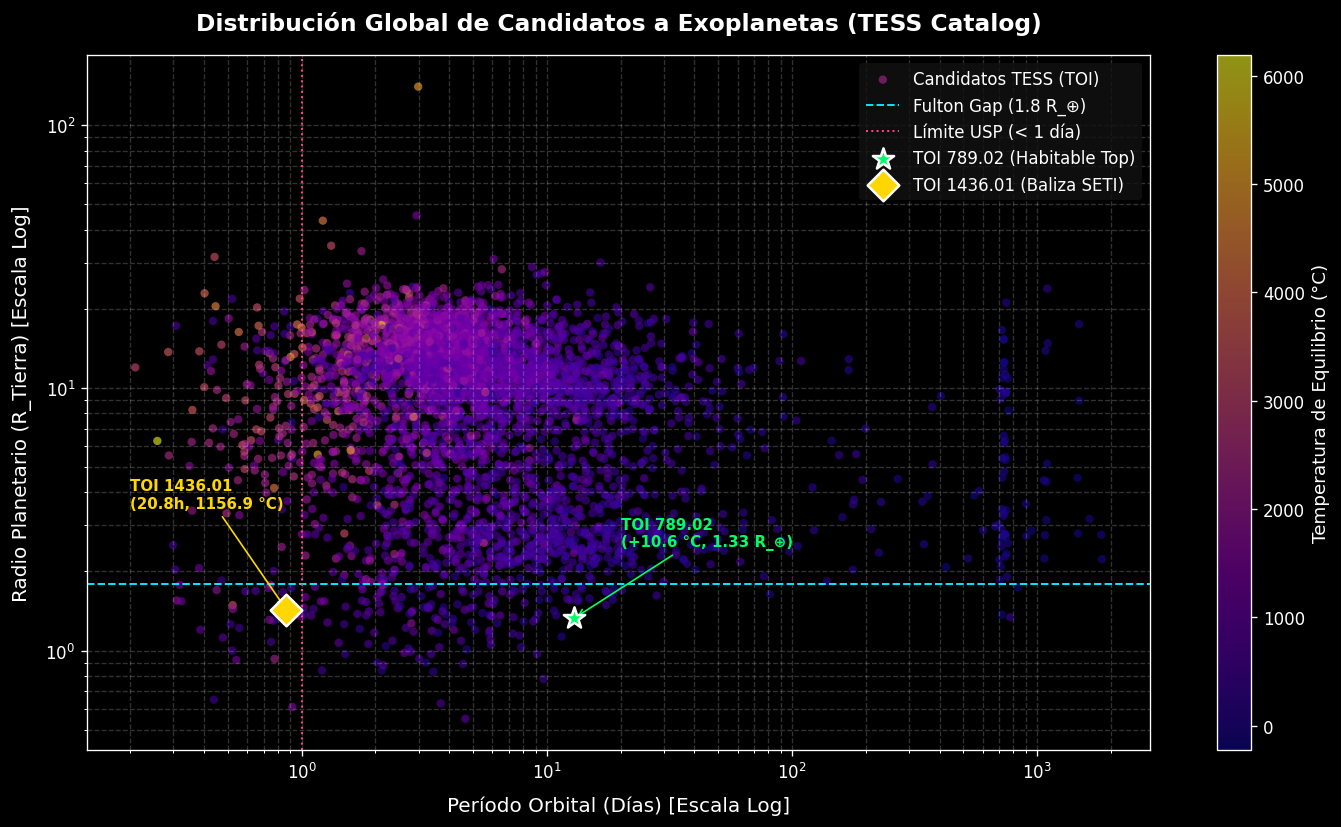

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuración estética
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

# 1. Graficar todos los 4,404 candidatos de TESS
scatter = ax.scatter(
    df_resultado["Periodo_Dias"],
    df_resultado["Radio_R_Earth"],
    c=df_resultado["Temp_Equilibrio_C"],
    cmap="plasma",
    alpha=0.6,
    s=25,
    edgecolors="none",
    label="Candidatos TESS (TOI)",
)

# Colorbar para la temperatura de equilibrio
cbar = plt.colorbar(scatter)
cbar.set_label("Temperatura de Equilibrio (°C)", fontsize=11, color="white")

# 2. Líneas de referencia astrofísicas
# Fulton Gap (Límite rocoso / gaseoso ~1.8 R_Earth)
ax.axhline(
    y=1.8,
    color="#00E5FF",
    linestyle="--",
    linewidth=1.2,
    label="Fulton Gap (1.8 R_⊕)",
)

# Límite USP (Período Ultra-Corto < 1 día)
ax.axvline(
    x=1.0,
    color="#FF4081",
    linestyle=":",
    linewidth=1.2,
    label="Límite USP (< 1 día)",
)

# 3. Destacar los candidatos prioritarios
# TOI 789.02 (Habitable)
ax.scatter(
    12.9707,
    1.33,
    color="#00FF66",
    s=180,
    marker="*",
    edgecolors="white",
    linewidth=1.5,
    zorder=5,
    label="TOI 789.02 (Habitable Top)",
)
ax.annotate(
    "TOI 789.02\n(+10.6 °C, 1.33 R_⊕)",
    (12.9707, 1.33),
    xytext=(20, 2.5),
    color="#00FF66",
    fontsize=9,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#00FF66", lw=1),
)

# TOI 1436.01 (SETI / USP)
ax.scatter(
    0.8676,
    1.43,
    color="#FFD700",
    s=180,
    marker="D",
    edgecolors="white",
    linewidth=1.5,
    zorder=5,
    label="TOI 1436.01 (Baliza SETI)",
)
ax.annotate(
    "TOI 1436.01\n(20.8h, 1156.9 °C)",
    (0.8676, 1.43),
    xytext=(0.2, 3.5),
    color="#FFD700",
    fontsize=9,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#FFD700", lw=1),
)

# 4. Ajustes de ejes logarítmicos
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Período Orbital (Días) [Escala Log]", fontsize=12, labelpad=8)
ax.set_ylabel(
    "Radio Planetario (R_Tierra) [Escala Log]", fontsize=12, labelpad=8
)
ax.set_title(
    "Distribución Global de Candidatos a Exoplanetas (TESS Catalog)",
    fontsize=14,
    pad=15,
    fontweight="bold",
)

ax.grid(True, which="both", linestyle="--", alpha=0.2)
ax.legend(loc="upper right", frameon=True, facecolor="#121212", edgecolor="none")

plt.tight_layout()
plt.show()


1. Este estudio aplicó un pipeline de filtrado y caracterización de datos sobre 4,404 candidatos a exoplanetas (TESS Objects of Interest - TOI) procesados por la misión TESS de la NASA.

El objetivo principal fue aislar candidatos de alto valor astrofísico en dos categorías clave:

Planetas rocosos en Zona Habitable (temperaturas aptas para agua líquida).

Candidatos de Período Ultra-Corto (USP) para estudios de firmas térmicas o tecnofirmas (SETI).

2. Metodología de Filtrado de DatosEl conjunto de datos original se sometió a las siguientes restricciones físicas y termodinámicas:Estimación del Radio Planetario ($R_p$): Cálculo derivado de la profundidad de tránsito y el radio de la estrella anfitriona.Temperatura de Equilibrio ($T_{\text{eq}}$): Estimación mediante la ley de Stefan-Boltzmann asumiendo albedo planetario moderado.Criterio de Habitabilidad: Rango de temperatura de $-93\text{ °C}$ a $+37\text{ °C}$, seleccionando únicamente objetos rocosos puros ($R_p < 1.8\,R_\oplus$, por debajo del Fulton Gap).

Resultados PrincipalesDe la población total analizada:76 candidatos se ubicaron dentro de los márgenes de temperatura de la Zona Habitable.5 candidatos cumplieron de manera estricta el criterio de ser rocosos puros ($R_p < 1.8\,R_\oplus$).27 candidatos se identificaron en la categoría USP (Período $< 1\text{ día}$).

3. Fichas Técnicas de Objetivos Prioritarios🏆 1. Top Candidato Habitable: TOI 789.02 (TIC 300710077)Radio Planetario: $1.33\ R_\oplus$ (Super-Tierra rocosa)Período Orbital: $12.97\text{ días}$Distancia Orbital: $0.108\text{ UA}$ (~16.16 millones de km)Temperatura de Equilibrio: $+10.6\text{ °C}$ (Entorno templado)Estrella Anfitriona: Enana M ($T_{\text{eff}} = 3,461\text{ K}$, $R_* = 0.371\ R_\odot$)Viabilidad Observacional: Profundidad de tránsito de $1.07\text{ ppt}$ ($0.107\%$). Altamente viable para seguimiento fotométrico desde telescopios terrestres de apertura moderada ($\ge 0.4\text{ m}$).

4. Top Candidato SETI / USP: TOI 1436.01 (TIC 154383539)Radio Planetario: $1.43\ R_\oplus$ (Cuerpo rocoso)Período Orbital: $0.8676\text{ días}$ ($20.8\text{ horas}$)Temperatura de Equilibrio: $+1,156.9\text{ °C}$Magnitudes Estelares: $V_{\text{mag}} = 12.01$, $T_{\text{mag}} = 11.09$, $G_{\text{mag}} = 11.66$Viabilidad Observacional: Excelente objetivo para espectroscopía de emisión térmica y eclipses secundarios mediante instrumentos del JWST (NIRSpec/MIRI).

5. Visualización Global y DiscusiónSe generó un diagrama de dispersión en escala logarítmica ($Radio$ vs. $Período$) codificado por temperatura de equilibrio. En la visualización se destacan dos características demográficas clave:Fulton Gap ($1.8\,R_\oplus$): La marcada escasez de planetas en esta frontera, la cual divide las Super-Tierras rocosas de los Sub-Neptunos con atmósferas volátiles.Gradiente Térmico: La clara transición cromática donde la temperatura disminuye a medida que aumenta el período orbital.

6. Conclusiones
El pipeline implementado demostró ser eficaz para procesar grandes catálogos astronómicos públicos y extraer de forma automatizada objetivos prioritarios. Los candidatos TOI 789.02 y TOI 1436.01 representan los casos más prometedores del análisis para futuras campañas de caracterización o documentación técnica.